In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
single_layer_file = "/Users/harukanarita/Desktop/Projects/fl_bar_processing/notebook/output/single_layer_props_with_gt.csv"
df_single = pd.read_csv(single_layer_file)
df_single

,c1_intensity_median,c1_intensity_mean,c1_intensity_max,c1_intensity_min,c1_intensity_center_5pixel,c2_intensity_median,c2_intensity_mean,c2_intensity_max,c2_intensity_min,c2_intensity_center_5pixel,c3_intensity_median,c3_intensity_mean,c3_intensity_max,c3_intensity_min,c3_intensity_center_5pixel,bar_id,area,layer_id,field_name,GroundTruth
0,107.0,107.199516,121,93,107.6,103.0,103.378476,121,87,102.4,2423.5,3115.194075,7998,240,5924.8,3,1022,Layer 2,A - 1_fld-2,1
1,107.0,107.166667,126,88,106.8,104.0,103.950828,118,86,106.0,2600.5,4191.283126,12854,265,10057.0,4,1170,Layer 2,A - 1_fld-2,1
2,107.0,107.282249,122,92,109.2,104.0,103.630178,116,86,104.4,2500.5,3334.929586,8624,260,7362.0,5,1067,Layer 2,A - 1_fld-2,1
3,107.0,106.536802,120,91,111.0,104.0,103.715102,121,85,110.2,2346.5,2797.446066,6602,277,5287.4,7,1044,Layer 2,A - 1_fld-2,1
4,107.0,106.856275,122,89,108.8,104.0,103.747470,117,78,102.2,3020.0,4717.412449,13524,258,10627.8,10,1287,Layer 2,A - 1_fld-2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10255,6384.5,8144.442473,20852,380,16291.8,2557.5,3327.631720,8611,159,6712.6,3220.5,4188.342473,10730,261,8463.0,164,1193,Layer 2,A - 9_fld-9,9
10256,10545.0,12890.975385,32587,434,31461.4,4248.0,5174.456000,13147,181,12958.0,5316.0,6695.373538,17588,259,17334.2,165,1207,Layer 2,A - 9_fld-9,9
10257,11157.0,10963.268957,22226,388,20417.6,3780.0,3873.802981,7671,166,7194.4,4110.0,4193.979909,8455,230,7618.0,167,1179,Layer 2,A - 9_fld-9,9
10258,15440.0,15798.752641,35042,404,30820.4,7531.0,7664.989434,16696,205,15544.0,8367.0,8652.315103,19706,283,17748.6,169,1377,Layer 2,A - 9_fld-9,9


In [4]:
colors = [
        '#1f77b4',  # Blue
        '#ff7f0e',  # Orange
        '#2ca02c',  # Green
        '#d62728',  # Red
        '#9467bd',  # Purple
        '#8c564b',  # Brown
        '#e377c2',  # Pink
        '#bcbd22',  # Olive
        '#17becf'   # Cyan
    ]

(0.0, 3000.0)

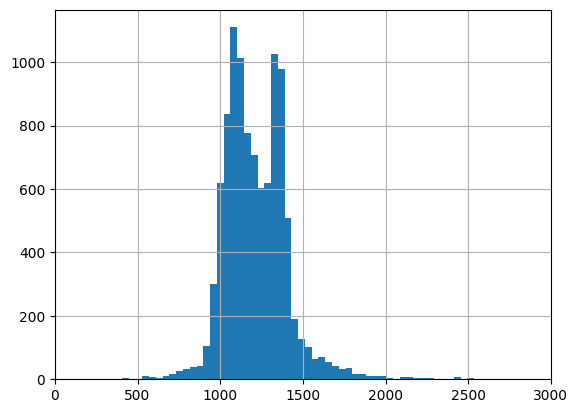

In [5]:
df_single["area"].hist(bins=200)
plt.xlim(0, 3000)

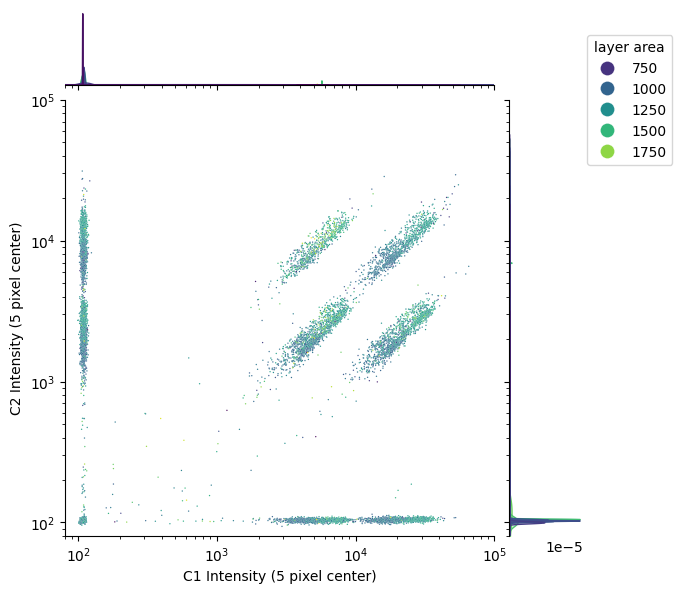

In [ ]:

g = sns.jointplot(
    data=df_single[(df_single["area"] < 2000) & (df_single["area"] > 500)], 
    x='c1_intensity_center_5pixel', 
    y='c2_intensity_center_5pixel', 
    hue='area',
    palette='viridis',
    s=1)

g.ax_joint.set_xscale('log')
g.ax_joint.set_yscale('log')
g.ax_marg_x.set_yscale('linear')
g.ax_marg_y.set_xscale('linear')

g.set_axis_labels('C1 Intensity (5 pixel center)', 'C2 Intensity (5 pixel center)')

g.ax_joint.set_xlim(8e1, 1e5)
g.ax_joint.set_ylim(8e1, 1e5)
handles, labels = g.ax_joint.get_legend_handles_labels()
g.ax_joint.legend(
    handles=handles, 
    labels=labels, 
    loc='center left', 
    bbox_to_anchor=(1.2, 1), 
    title='layer area', 
    scatterpoints=3, 
    markerscale=10
)

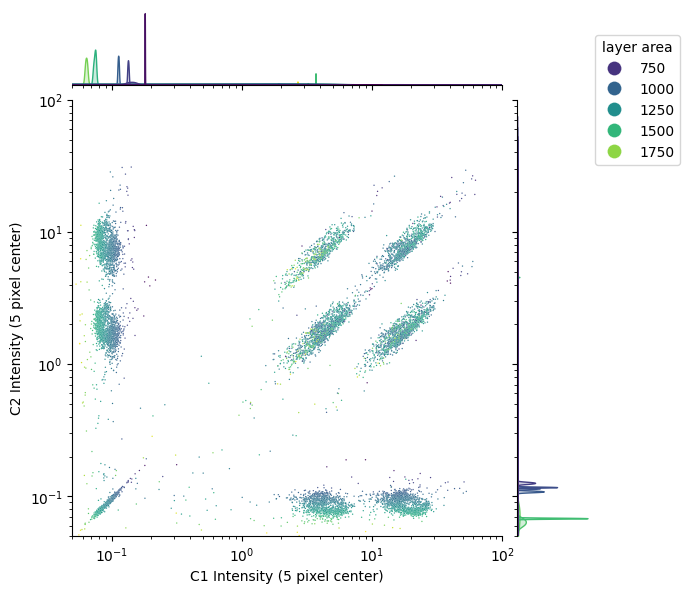

In [7]:
df_single["c1_intensity_center_5pixel_dv_area"] = df_single["c1_intensity_center_5pixel"] / df_single["area"]
df_single["c2_intensity_center_5pixel_dv_area"] = df_single["c2_intensity_center_5pixel"] / df_single["area"]

g = sns.jointplot(
    data=df_single[(df_single["area"] < 2000) & (df_single["area"] > 500)], 
    x='c1_intensity_center_5pixel_dv_area', 
    y='c2_intensity_center_5pixel_dv_area', 
    hue='area',
    palette='viridis',
    s=1)

g.ax_joint.set_xscale('log')
g.ax_joint.set_yscale('log')
g.ax_marg_x.set_yscale('linear')
g.ax_marg_y.set_xscale('linear')

g.set_axis_labels('C1 Intensity (5 pixel center)', 'C2 Intensity (5 pixel center)')

g.ax_joint.set_xlim(5e-2, 1e2)
g.ax_joint.set_ylim(5e-2, 1e2)
handles, labels = g.ax_joint.get_legend_handles_labels()
g.ax_joint.legend(
    handles=handles, 
    labels=labels, 
    loc='center left', 
    bbox_to_anchor=(1.2, 1), 
    title='layer area', 
    scatterpoints=3, 
    markerscale=10
)

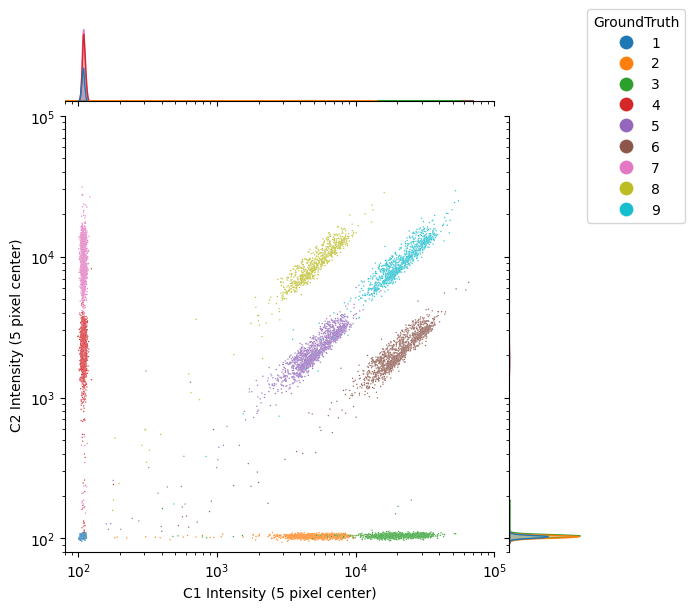

In [8]:
import seaborn as sns

g = sns.jointplot(
    data=df_single, 
    x='c1_intensity_center_5pixel', 
    y='c2_intensity_center_5pixel', 
    hue='GroundTruth',
    palette=colors,
    s=1)

g.ax_joint.set_xscale('log')
g.ax_joint.set_yscale('log')
g.ax_marg_x.set_yscale('linear')
g.ax_marg_y.set_xscale('linear')

g.set_axis_labels('C1 Intensity (5 pixel center)', 'C2 Intensity (5 pixel center)')

g.ax_joint.set_xlim(8e1, 1e5)
g.ax_joint.set_ylim(8e1, 1e5)
handles, labels = g.ax_joint.get_legend_handles_labels()
g.ax_joint.legend(
    handles=handles, 
    labels=labels, 
    loc='center left', 
    bbox_to_anchor=(1.2, 1), 
    title='GroundTruth', 
    scatterpoints=3, 
    markerscale=10
)

In [9]:
splitpool_file = "/Users/harukanarita/Desktop/Projects/fl_bar_processing/notebook/output/0529_layer2_filt_900-2000.csv"
df_splitpool = pd.read_csv(splitpool_file)

In [10]:
df_splitpool_layer_2 = df_splitpool[df_splitpool["layer_id"] == "Layer 2"]
df_splitpool_layer_2["type"] = "splitpool"
df_single["type"] = "single_layer"
df_layer_2 = pd.concat([df_single, df_splitpool_layer_2], ignore_index=True)
df_layer_2

/var/folders/p_/n_q7ts0n2j1g8yqgq_j75j6h0000gn/T/ipykernel_895/1509478955.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_splitpool_layer_2["type"] = "splitpool"


,c1_intensity_median,c1_intensity_mean,c1_intensity_max,c1_intensity_min,c1_intensity_center_5pixel,c2_intensity_median,c2_intensity_mean,c2_intensity_max,c2_intensity_min,c2_intensity_center_5pixel,...,x_center,y_center_ratio,original_label,layer area,mask area,area_ratio,parent_folder,date,layer_2_blue_intensity_class,layer_4_blue_intensity_class
0,107.0,107.199516,121,93,107.6,103.0,103.378476,121,87,102.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,107.0,107.166667,126,88,106.8,104.0,103.950828,118,86,106.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,107.0,107.282249,122,92,109.2,104.0,103.630178,116,86,104.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,107.0,106.536802,120,91,111.0,104.0,103.715102,121,85,110.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,107.0,106.856275,122,89,108.8,104.0,103.747470,117,78,102.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26429,3199.0,2882.154020,4632,0,4394.4,1589.0,1438.150623,2325,0,2172.2,...,79.0,0.339806,3.0,883.0,4427.0,0.199458,20250804-102218,529.0,True,True
26430,255.5,588.878182,3964,0,161.2,1640.5,1845.814545,9077,0,4273.6,...,67.0,0.327103,4.0,1100.0,5052.0,0.217736,20250804-102218,529.0,True,True
26431,3539.0,3337.750961,8553,1,5036.0,1399.0,1317.695619,2598,1,2299.4,...,81.0,0.358491,1.0,1301.0,5070.0,0.256607,20250804-102218,529.0,True,True
26432,141.0,289.982523,1814,1,151.8,4886.0,4890.427812,10599,1,8546.2,...,72.0,0.324074,2.0,1316.0,5445.0,0.241690,20250804-102218,529.0,True,True


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/axisgrid.py:1832: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  func(x=self.x, y=self.y, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/axisgrid.py:1883: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  func(x=self.x, ax=self.ax_marg_x, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/axisgrid.py:1889: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  func(y=self.y, ax=self.ax_marg_y, **kwargs)


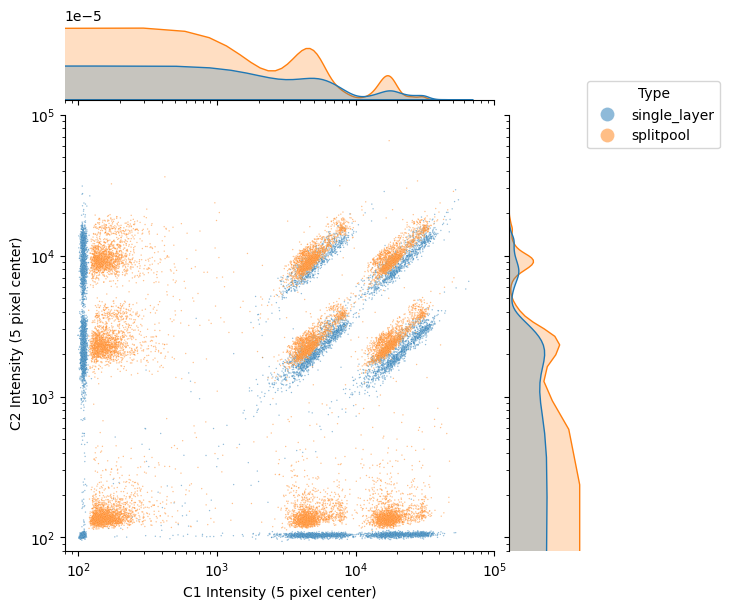

In [11]:
import seaborn as sns

g = sns.jointplot(
    data=df_layer_2, 
    x='c1_intensity_center_5pixel', 
    y='c2_intensity_center_5pixel', 
    hue='type',
    palette=colors,
    alpha=0.5,
    s=1)

g.ax_joint.set_xscale('log')
g.ax_joint.set_yscale('log')
g.ax_marg_x.set_yscale('linear')
g.ax_marg_y.set_xscale('linear')

g.set_axis_labels('C1 Intensity (5 pixel center)', 'C2 Intensity (5 pixel center)')

g.ax_joint.set_xlim(8e1, 1e5)
g.ax_joint.set_ylim(8e1, 1e5)
handles, labels = g.ax_joint.get_legend_handles_labels()
g.ax_joint.legend(
    handles=handles, 
    labels=labels, 
    loc='center left', 
    bbox_to_anchor=(1.2, 1), 
    title='Type', 
    scatterpoints=3, 
    markerscale=10
)

P(Z=k|x) = (π_k × N(x|μ_k, σ_k²)) / Σ_j(π_j × N(x|μ_j, σ_j²))

- pi_k: π_k
- mu_k: μ_k
- sigma_k: σ_k²
- likelihood: N(x|μ_k, σ_k²)
- marginal_likelihood: Σ_j(π_j × N(x|μ_j, σ_j²))
- posterior: P(Z=k|x)

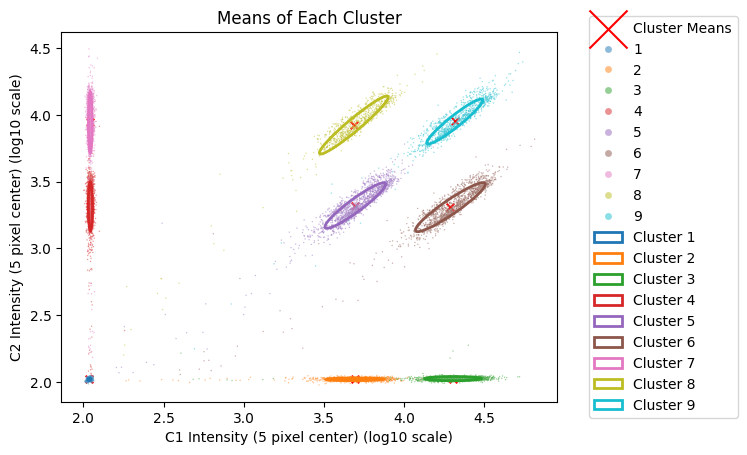

In [ ]:
from matplotlib.patches import Ellipse
from scipy.stats import multivariate_normal

mus = []
covs = []
pis = []

for i in range(1, 10):
    df_cluster = df_single[df_single["GroundTruth"] == i]
    cluster_k_data = df_cluster.loc[:, ['c1_intensity_center_5pixel', 'c2_intensity_center_5pixel']].values
    cluster_k_data_log = np.log10(cluster_k_data + 1)

    mu_k = np.mean(cluster_k_data_log, axis=0)
    cov_k = np.cov(cluster_k_data_log.T)
    pi_k = len(cluster_k_data_log) / len(df_single)

    mus.append(mu_k)
    covs.append(cov_k)
    pis.append(pi_k)

mus = np.array(mus)
covs = np.array(covs)
pis = np.array(pis)

plt.scatter(mus[:, 0], mus[:, 1], c='red', marker='x', s=30, label='Cluster Means')

df_single["c1_intensity_center_5pixel_log"] = np.log10(df_single["c1_intensity_center_5pixel"] + 1)
df_single["c2_intensity_center_5pixel_log"] = np.log10(df_single["c2_intensity_center_5pixel"] + 1)

sns.scatterplot(
    data=df_single, 
    x='c1_intensity_center_5pixel_log', 
    y='c2_intensity_center_5pixel_log', 
    hue='GroundTruth',
    palette=colors,
    alpha=0.5,
    s=1)
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('C1 Intensity (5 pixel center) (log10 scale)')
plt.ylabel('C2 Intensity (5 pixel center) (log10 scale)')
plt.title('Means of Each Cluster')

for i, (mu, cov) in enumerate(zip(mus, covs)):
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
    width, height = 2 * np.sqrt(eigvals)
    ellipse = Ellipse(xy=mu, width=width, height=height, angle=angle, edgecolor=colors[i], facecolor='none', lw=2, label=f'Cluster {i+1}')
    plt.gca().add_patch(ellipse)
    plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), markerscale=5)

plt.show()

In [24]:
def set_prob_and_likelihood(row):
    xy = row[['c1_intensity_center_5pixel_log', 'c2_intensity_center_5pixel_log']].values
    for k in range(1, 10):
        likelihood = multivariate_normal.pdf(xy, mean=mus[k-1], cov=covs[k-1])
        marginal_likelihood = sum(multivariate_normal.pdf(xy, mean=mus[j], cov=covs[j]) * pis[j] for j in range(len(pis)))
        posterior = likelihood * pis[k-1] / marginal_likelihood if marginal_likelihood > 0 else 0
        
        row[f"likelihood_{k}"] = likelihood
        row[f"marginal_likelihood_{k}"] = marginal_likelihood
        row[f"posterior_{k}"] = posterior
    row["confidence"] = max(row[f"posterior_{k}"] for k in range(1, 10))
    row["predicted_label"] = np.argmax([row[f"posterior_{k}"] for k in range(1, 10)]) + 1
    row["is_correct"] = row["predicted_label"] == row["GroundTruth"]
    return row

In [25]:
df_single = df_single.apply(set_prob_and_likelihood, axis=1)
df_single

,c1_intensity_median,c1_intensity_mean,c1_intensity_max,c1_intensity_min,c1_intensity_center_5pixel,c2_intensity_median,c2_intensity_mean,c2_intensity_max,c2_intensity_min,c2_intensity_center_5pixel,...,posterior_7,likelihood_8,marginal_likelihood_8,posterior_8,likelihood_9,marginal_likelihood_9,posterior_9,confidence,predicted_label,is_correct
0,107.0,107.199516,121,93,107.6,103.0,103.378476,121,87,102.4,...,5.175367e-17,5.007615e-18,89.732570,4.073946e-21,5.020913e-38,89.732570,5.459078e-41,1.000000,1,True
1,107.0,107.166667,126,88,106.8,104.0,103.950828,118,86,106.0,...,1.520888e-16,1.934878e-17,39.614059,3.565650e-20,1.572121e-38,39.614059,3.871893e-41,1.000000,1,True
2,107.0,107.282249,122,92,109.2,104.0,103.630178,116,86,104.4,...,9.585592e-17,7.519428e-18,88.058365,6.233740e-21,7.117758e-38,88.058365,7.886046e-41,1.000000,1,True
3,107.0,106.536802,120,91,111.0,104.0,103.715102,121,85,110.2,...,9.876272e-15,3.663566e-17,1.853507,1.442927e-18,4.961280e-38,1.853507,2.611478e-39,1.000000,1,True
4,107.0,106.856275,122,89,108.8,104.0,103.747470,117,78,102.2,...,7.459824e-17,3.731374e-18,77.881307,3.497598e-21,9.193824e-38,77.881307,1.151727e-40,1.000000,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10255,6384.5,8144.442473,20852,380,16291.8,2557.5,3327.631720,8611,159,6712.6,...,0.000000e+00,4.013637e-23,1.215851,2.409863e-24,1.222132e+01,1.215851,9.806741e-01,0.980674,9,True
10256,10545.0,12890.975385,32587,434,31461.4,4248.0,5174.456000,13147,181,12958.0,...,0.000000e+00,2.307809e-24,0.951690,1.770267e-25,9.754180e+00,0.951690,9.999585e-01,0.999959,9,True
10257,11157.0,10963.268957,22226,388,20417.6,3780.0,3873.802981,7671,166,7194.4,...,0.000000e+00,1.131598e-28,0.473839,1.743396e-29,4.757750e+00,0.473839,9.796203e-01,0.979620,9,True
10258,15440.0,15798.752641,35042,404,30820.4,7531.0,7664.989434,16696,205,15544.0,...,0.000000e+00,1.967164e-18,0.304514,4.715929e-19,3.121184e+00,0.304514,9.999963e-01,0.999996,9,True


In [26]:
df_single.to_csv("output/single_layer_props_with_posterior.csv", index=False)

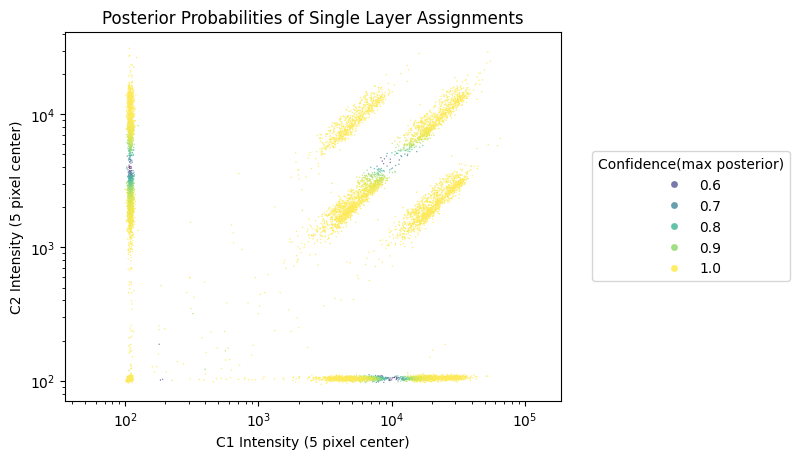

In [44]:
sns.scatterplot(
    data=df_single, 
    x='c1_intensity_center_5pixel', 
    y='c2_intensity_center_5pixel', 
    hue='confidence',
    palette='viridis',
    alpha=0.7,
    s=1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('C1 Intensity (5 pixel center)')
plt.ylabel('C2 Intensity (5 pixel center)')
plt.title('Posterior Probabilities of Single Layer Assignments')
plt.axis('equal')

plt.legend(
    loc='center left', 
    bbox_to_anchor=(1.05, 0.5), 
    title='Confidence(max posterior)', 
    scatterpoints=1, 
    markerscale=5
)


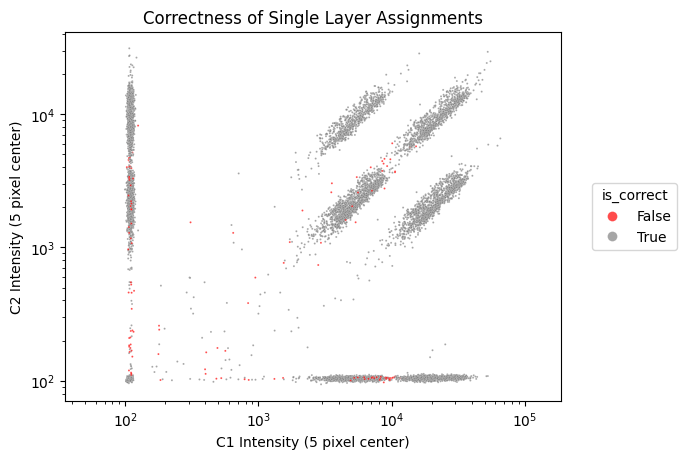

In [30]:
sns.scatterplot(
    data=df_single, 
    x='c1_intensity_center_5pixel', 
    y='c2_intensity_center_5pixel', 
    hue='is_correct',
    palette={True: 'gray', False: 'red'},
    alpha=0.7,
    s=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('C1 Intensity (5 pixel center)')
plt.ylabel('C2 Intensity (5 pixel center)')
plt.title('Correctness of Single Layer Assignments')
plt.axis('equal')

plt.legend(
    loc='center left', 
    bbox_to_anchor=(1.05, 0.5), 
    title='is_correct', 
    scatterpoints=1, 
    markerscale=5
)


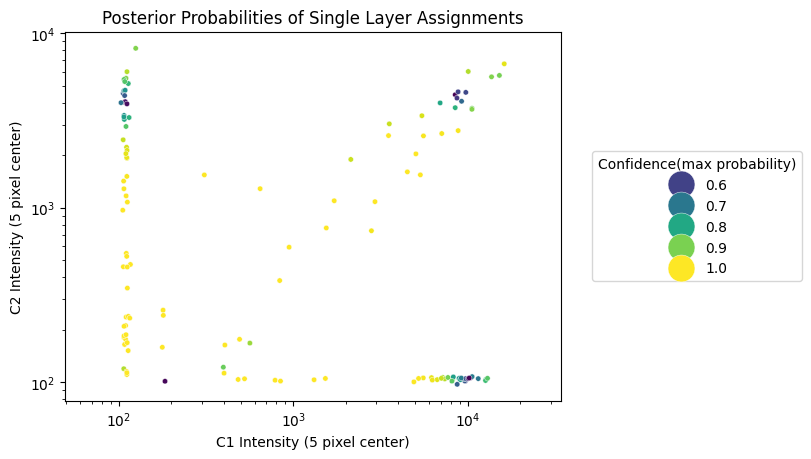

In [47]:
sns.scatterplot(
    data=df_single[df_single['is_correct'] == False], 
    x='c1_intensity_center_5pixel', 
    y='c2_intensity_center_5pixel', 
    hue='confidence',
    palette='viridis',
    s=15)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('C1 Intensity (5 pixel center)')
plt.ylabel('C2 Intensity (5 pixel center)')
plt.title('Posterior Probabilities of Single Layer Assignments')
plt.axis('equal')

plt.legend(
    loc='center left', 
    bbox_to_anchor=(1.05, 0.5), 
    title='Confidence(max probability)', 
    scatterpoints=1, 
    markerscale=5
)


In [42]:
def get_recovery_accuracy_curve(df):
    confidences = df["confidence"].values
    is_correct = df["is_correct"].values

    thresholds = np.arange(0.1, 1.0, 0.05)  # 0.1, 0.15, 0.20, ..., 0.95
    recoveries = []
    accuracies = []

    for threshold in thresholds:
        above_threshold = confidences >= threshold
        recovery = np.sum(above_threshold) / len(confidences)
        
        correct_predictions = is_correct[above_threshold]
        accuracy = np.sum(correct_predictions) / np.sum(above_threshold)
        
        recoveries.append(recovery)
        accuracies.append(accuracy)

    recoveries = np.array(recoveries)
    accuracies = np.array(accuracies)

    plt.figure(figsize=(6, 6))
    plt.plot(recoveries, accuracies, 'b-', linewidth=2, label='Confidence-Recovery Curve')
    plt.xlabel('Recovery')
    plt.ylabel('Accuracy')
    plt.title('Confidence-Recovery Curve (Posterior)')
    plt.grid(True, alpha=0.3)


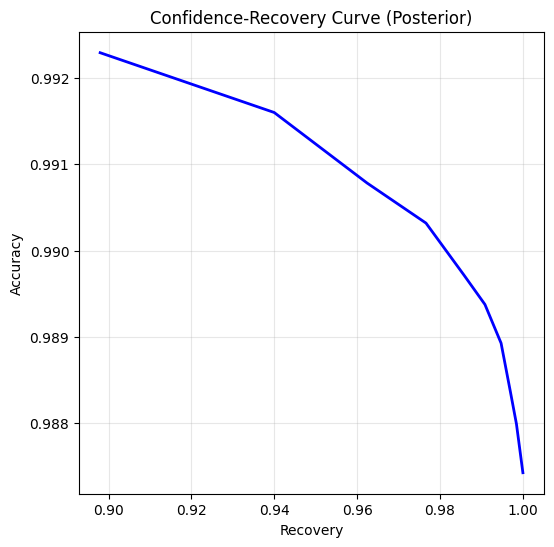

In [43]:
get_recovery_accuracy_curve(df_single)